In [1]:
from pathlib import Path
import re
from collections import Counter
import matplotlib.pyplot as plt

SZ: files=2522, tokens(after cleaning)=1172039
Zeit: files=6281, tokens(after cleaning)=4315585
Spiegel: files=9190, tokens(after cleaning)=4635716
TAZ: files=4629, tokens(after cleaning)=1953123


,SZ,Zeit,Spiegel,TAZ
word,,,,
israel,9.706162,5.556605,6.444743,6.722567
hamas,7.363236,3.487592,4.365453,4.323332
menschen,3.906013,3.486202,3.542279,3.848196
gaza,5.548450,1.951531,2.515469,3.704836
deutschland,2.249925,2.470580,2.333836,2.160130
israelischen,2.772945,1.726070,2.293281,2.456579
krieg,3.889802,1.778438,2.038089,2.035714
israels,2.795982,1.509413,2.190600,1.763330
trump,0.682571,2.073184,2.373743,1.307137


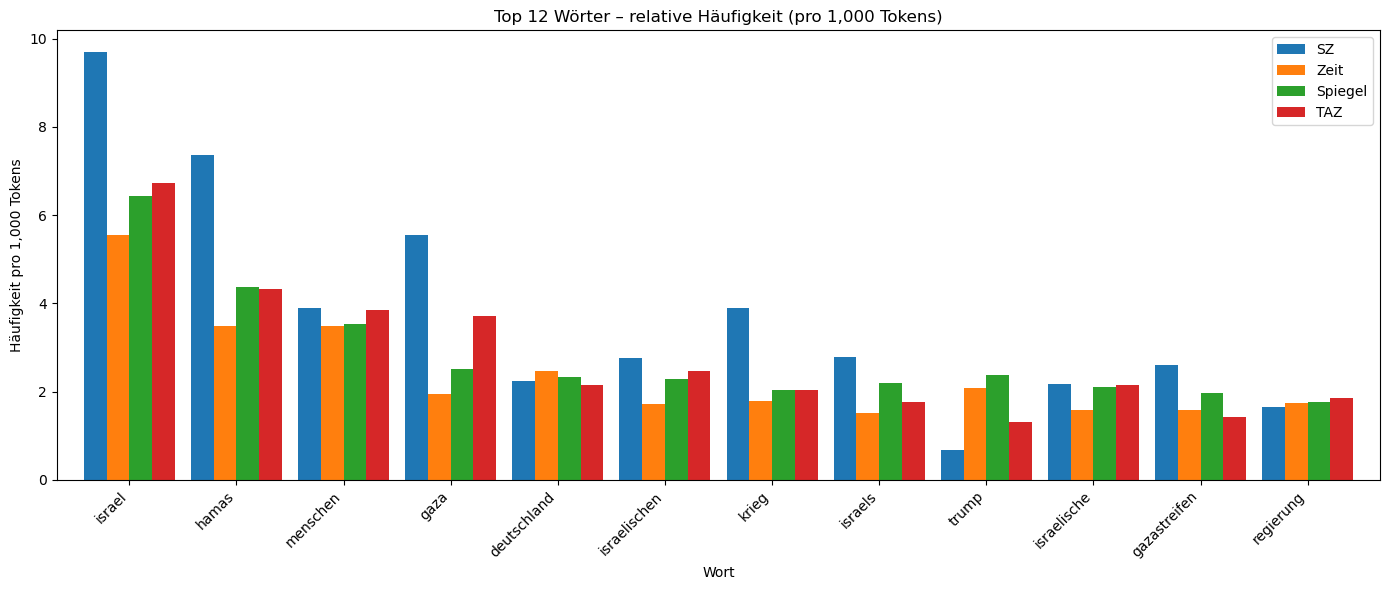


Top distinctive words per journal (delta vs mean of other journals):


,journal,word,delta_vs_others
1137566,TAZ,nen,3.590786
4,SZ,israel,3.464857
6,SZ,hamas,3.304444
1134178,TAZ,taz,2.854769
48,SZ,gaza,2.824505
10,SZ,krieg,1.939055
0,SZ,politik,1.591345
738725,Spiegel,netanyahu,1.453209
174,SZ,netanjahu,1.397079
354,SZ,biden,1.149912


In [8]:
from pathlib import Path
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CONFIG
# =========================
BASE_DIR = Path("/home/arabella/Desktop/Journals")
# Example structure:
# /raw/
#   sz_txt/
#   faz_txt/
#   taz_txt/

JOURNAL_DIRS = {
    "SZ": BASE_DIR / "sz_txt",
     "Zeit": BASE_DIR / "diezeit_txt_clean",
     "Spiegel": BASE_DIR / "derspiegel_txt_clean",
    "TAZ": BASE_DIR / "taz_txt_clean",
}
MAX_FILES = None  # None = all
TOP_N = 12
NORM_PER = 1_000  # relative frequency: occurrences per 10,000 tokens

STOPWORDS = {
    "der", "die", "zeit","das","spiegel", "ein", "eine", "einer", "eines", "einem", "einen","was","sagt","sei", "soll","muss",
    "und", "oder", "aber", "wenn", "dann", "denn", "dem","für", "mit", "ohne", "gegen", "über", "unter", "zwischen", "hat",
    "zu", "zum", "zur", "von", "vom", "im", "in", "am", "an", "auf", "aus", "bei", "mit", "nach", "vor", "über", "unter",
    "ist", "sind", "war", "waren", "sein", "wird", "werden", "wurde", "wurden","gibt","hier",
    "ich", "du", "er", "sie", "es", "wir", "ihr", "man","den","als","sich","des", "viele","jetzt",
    "mich", "dich", "ihn", "uns", "euch", "seit","nun","haben","will","dort","kann","alle", "können",
    "mein", "meine", "dein", "deine", "sein", "seine", "ihr", "ihre","haben","zwei","durch","immer","wieder",
    "nicht", "kein", "keine", "ja", "nein", "hatte","seiner","doch", "bis","weil","sagte",
    "auch", "noch", "nur", "schon", "sehr", "mehr", "weniger", "so", "wie","habe","damit","heute",
    "dass", "daß", "dies", "diese", "dieser", "dieses", "jener", "jene", "jenes","online","oktober","selbst"
}

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s]", " ", text)
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def journal_word_counts(journal_dir: Path, max_files=None):
    files = sorted(journal_dir.glob("*.txt"))
    if max_files is not None:
        files = files[:max_files]

    all_words = []
    for txt_file in files:
        text = txt_file.read_text(encoding="utf-8", errors="ignore")
        all_words.extend(tokenize(text))

    counts = Counter(all_words)
    total_tokens = len(all_words)
    return counts, total_tokens, len(files)

def to_per_n(count, total_tokens, per=NORM_PER):
    if total_tokens == 0:
        return 0.0
    return (count / total_tokens) * per

def main():
    # --- compute counts per journal ---
    journal_counts = {}
    journal_tokens = {}
    journal_files = {}

    for jname, jdir in JOURNAL_DIRS.items():
        counts, total_tokens, nfiles = journal_word_counts(jdir, MAX_FILES)
        journal_counts[jname] = counts
        journal_tokens[jname] = total_tokens
        journal_files[jname] = nfiles
        print(f"{jname}: files={nfiles}, tokens(after cleaning)={total_tokens}")

    if not journal_counts:
        print("No journals configured. Fill JOURNAL_DIRS.")
        return

    # --- choose comparison vocabulary: top words across ALL journals combined ---
    global_counts = Counter()
    for jname, c in journal_counts.items():
        global_counts.update(c)

    top_words = [w for w, _ in global_counts.most_common(TOP_N)]

    # --- build a dataframe of relative frequencies ---
    rows = []
    for w in top_words:
        row = {"word": w}
        for jname in JOURNAL_DIRS.keys():
            row[jname] = to_per_n(journal_counts[jname].get(w, 0), journal_tokens[jname], NORM_PER)
        rows.append(row)

    df_plot = pd.DataFrame(rows).set_index("word")
    display(df_plot)

    # --- plot grouped bar chart ---
    ax = df_plot.plot(kind="bar", figsize=(14, 6), width=0.85)
    ax.set_title(f"Top {TOP_N} Wörter – relative Häufigkeit (pro {NORM_PER:,} Tokens)")
    ax.set_xlabel("Wort")
    ax.set_ylabel(f"Häufigkeit pro {NORM_PER:,} Tokens")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Optional: print most distinctive words per journal (difference vs mean of others)
    # (useful for “what stands out” rather than “most frequent overall”)
    distinct_rows = []
    for jname in JOURNAL_DIRS.keys():
        others = [o for o in JOURNAL_DIRS.keys() if o != jname]
        for w in global_counts.keys():
            v = to_per_n(journal_counts[jname].get(w, 0), journal_tokens[jname], NORM_PER)
            omean = np.mean([to_per_n(journal_counts[o].get(w, 0), journal_tokens[o], NORM_PER) for o in others]) if others else 0
            distinct_rows.append({"journal": jname, "word": w, "delta_vs_others": v - omean})

    distinct_df = pd.DataFrame(distinct_rows)
    top_distinct = distinct_df.sort_values("delta_vs_others", ascending=False).groupby("journal").head(15)
    print("\nTop distinctive words per journal (delta vs mean of other journals):")
    display(top_distinct)

if __name__ == "__main__":
    main()

In [48]:
from pathlib import Path
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# CONFIG
# =========================
#DATA_DIR = Path("articles")
MAX_FILES = None          # e.g. 300 for testing, None for all
MIN_WORD_LEN = 3
SMOOTHING_WINDOW_DAYS = 3  # rolling average for plots

KEYWORDS = [
    "Geisel", "Freiheit", "Schlachtruf", "Dörfer", "Opfer", "Schuld", "Parole", "Städte",
    "Zivilisten", "Vergebung", "Menschliches Schutzschild", "Gaza", "Kinder", "Sieg",
    "Machtmissbrauch", "Gazastreifen", "Minderjährige", "Selbstverteidigung",
    "Vergeltungsschlag", "Israel", "Jugendliche", "Demokratie", "Handlungsspielraum",
    "Exil", "Junge", "Toleranz", "Barbarei", "Diaspora", "Mädchen", "Schuld",
    "Propaganda", "Infrastruktur", "Baby", "Schmerz", "Verbrechen Menschlichkeit",
    "Grenzübergang", "Säugling", "Solidarität", "Kontroverse", "Umstrittene Gebiete",
    "Gefangene", "Legitimität", "Terrorsymbol", "Palästinenserstaat", "Frauen",
    "Rechtfertigung", "Bestialität", "Tunnel", "Männer", "Sicherheit", "Kälte",
    "Tunnelnetz", "Alte", "Gerechtigkeit", "Korruption", "sichere Zone", "Juden",
    "Schutz", "Protest", "Schutzbunker", "Muslime", "Vergeltung", "Straßenprotest",
    "Territorium", "Palästinenser", "Hass", "Demonstration", "Kriegszone", "Israelis",
    "Rache", "Recht", "Kriegsgebiet", "Menschen", "Lust", "Gesetz", "Naher Osten",
    "Bürger", "Gelüste", "Existenzrecht", "Mittlerer Osten", "Einwohner", "Zuflucht",
    "Verbot", "Gefängnis", "Bewohner", "Überleben", "Hassworte", "Käfig", "Diaspora",
    "Widerstand", "Gewalttaten", "Tunnel", "Wohnhäuser", "Exil", "Versammlung",
    "Kommandozentrale", "Christen", "Trauer", "Kundgebung", "Arabischer Staat",
    "Homosexuelle", "Schrecken", "Versammlungsrecht", "Besetztes Gebiet", "Araber",
    "Gedenken", "Hetzparolen", "Massengrab", "Krankenhaus", "AusnahmesituationKindermörder",
    "Schlachtfeld", "Journalist", "Not", "Hilfe", "Schutzraum", "Klinik", "Notsituation",
    "Hilfslieferung", "Schutzzone", "Patienten", "Leid", "Blockade", "Krisengebiet",
    "Ärzte", "Koexoistence", "Sanktion", "Krankenhaus", "Sanitäter", "Bedrohung",
    "Abriegelung", "Vorort", "Leichen", "Frieden", "Bombardement", "Gaza-Stadt",
    "Leichenberge", "Deeskalation", "Rakete", "Ziele", "Töchter", "Versöhnung", "Bombe",
    "urbanes Gelände", "Söhne", "Rettung", "Bombardierung", "Front", "Väter", "Kontext",
    "Völerrecht", "Westjordanland", "Mütter", "Stellvertreterkrieg", "Hilfsgüter",
    "Region", "Großmütter", "Rebellion", "Unterstützung", "Schule", "Enkel",
    "Freiheitskampf", "Zwei-Staaten-Lösung", "Kindergärten", "Personen", "Kolonialismus",
    "Flugabwehr", "geschützte Plätze", "Staatsbürger", "Apartheid", "Bombenhagel",
    "Häuserblock", "Familien", "Wasser", "Entlassung", "geschützter Korridor",
    "Mitbürger", "Brot", "Gewaltspirale", "Fluchtkorridor", "palästinensisches Volk",
    "Hunger", "Kritik", "Fläche", "Bevölkerung", "Feuerpause", "Nahostkonflikt",
    "Flüchtlingslager", "Arbeitskräfte", "Kollektivbestrafung", "Vermisste",
    "UN-Resolution", "Geflüchtete", "Todesstrafe", "Flüchtlinge", "Gefangenenaustausch",
    "Entführte", "Fake News",
]
from pathlib import Path
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# CONFIG
# =========================
# HELPERS (unchanged, except STOPWORDS must exist)
# =========================
def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s\-]", " ", text)
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) >= MIN_WORD_LEN]

def parse_date_from_filename(filename: str):
    """
    Parse date ONLY from filename.
    Works with e.g. '2024_10_04_something.txt' (and also with - separators).
    """
    s = filename.strip()

    # first try: YYYY_MM_DD or YYYY-MM-DD
    m = re.search(r"(\d{4})[_-](\d{2})[_-](\d{2})", s)
    if m:
        yyyy, mm, dd = m.group(1), m.group(2), m.group(3)
        return pd.to_datetime(f"{yyyy}-{mm}-{dd}", errors="coerce")

    # fallback: YYYYMMDD
    m = re.search(r"(\d{4})(\d{2})(\d{2})", s)
    if m:
        yyyy, mm, dd = m.group(1), m.group(2), m.group(3)
        return pd.to_datetime(f"{yyyy}-{mm}-{dd}", errors="coerce")

    return pd.NaT

def count_keywords(tokens, keywords):
    token_counter = Counter(tokens)
    joined = " ".join(tokens)
    out = {}
    for kw in keywords:
        k = kw.lower().strip()
        if not k:
            continue
        if " " in k:
            pattern = r"(?<!\S)" + re.escape(k) + r"(?!\S)"
            out[k] = len(re.findall(pattern, joined))
        else:
            out[k] = token_counter.get(k, 0)
    return out

# =========================
# MAIN (multi-journal)
# =========================
def main():
    """
    Multi-journal loader + keyword counting + relative-frequency trends.
    Date is parsed ONLY from filename (YYYY_MM_DD / YYYY-MM-DD / YYYYMMDD anywhere in name).
    No category is used.
    Includes in-loop debug prints for date parsing failures.
    """

    def parse_date_from_filename(filename: str):
        s = filename.strip()

        # YYYY_MM_DD or YYYY-MM-DD anywhere in filename
        m = re.search(r"(\d{4})[_-](\d{2})[_-](\d{2})", s)
        if m:
            yyyy, mm, dd = m.group(1), m.group(2), m.group(3)
            return pd.to_datetime(f"{yyyy}-{mm}-{dd}", errors="coerce")

        # YYYYMMDD anywhere in filename
        m = re.search(r"(\d{4})(\d{2})(\d{2})", s)
        if m:
            yyyy, mm, dd = m.group(1), m.group(2), m.group(3)
            return pd.to_datetime(f"{yyyy}-{mm}-{dd}", errors="coerce")

        return pd.NaT

    all_records = []
    bad_date_files = []
    fail_printed = Counter()  # show only first N failures per journal

    for journal, data_dir in JOURNAL_DIRS.items():
        files = sorted(data_dir.glob("*.txt"))
        if MAX_FILES is not None:
            files = files[:MAX_FILES]

        print(f"{journal}: loaded files: {len(files)}")

        for fp in files:
            # parse date ONLY from filename
            dt = parse_date_from_filename(fp.name)
            if pd.isna(dt):
                bad_date_files.append({"journal": journal, "file": fp.name})
                if fail_printed[journal] < 5:
                    print(f"[DATE PARSE FAIL] {journal}: {fp.name}")
                    fail_printed[journal] += 1
                continue

            text = fp.read_text(encoding="utf-8", errors="ignore")

            # IMPORTANT: since date is NOT from first line, do NOT remove first line
            body = text

            tokens = tokenize(body)
            kw_counts = count_keywords(tokens, KEYWORDS)

            rec = {
                "journal": journal,
                "file": fp.name,
                "date": dt.normalize(),
                "token_count": len(tokens),
            }
            rec.update(kw_counts)
            all_records.append(rec)

    # quick summary diagnostics
    print(f"Total parsed articles: {len(all_records)}")
    print(f"Total date-parse failures: {len(bad_date_files)}")
    if bad_date_files:
        print("Example failures (first 20):")
        for x in bad_date_files[:20]:
            print(x["journal"], "->", x["file"])
        pd.DataFrame(bad_date_files).to_csv("files_with_bad_date_MULTI.csv", index=False, encoding="utf-8")
        print("Saved files_with_bad_date_MULTI.csv")

    if not all_records:
        print("No valid records found. Your filenames may not contain a parseable date.")
        return

    df = pd.DataFrame(all_records).sort_values(["journal", "date"])
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df.to_csv("article_level_time_data_MULTI.csv", index=False, encoding="utf-8")
    print("Saved article_level_time_data_MULTI.csv")

    keyword_cols = [c for c in df.columns if c not in {"journal", "file", "date", "token_count"}]
    for c in keyword_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    # -------------------------
    # Daily overall trends PER JOURNAL (relative per 1000 tokens)
    # -------------------------
    agg = {"token_count": "sum"}
    agg.update({k: "sum" for k in keyword_cols})

    daily = (
        df.groupby(["journal", "date"], as_index=False)
          .agg(agg)
          .sort_values(["journal", "date"])
    )

    daily_article_counts = (
        df.groupby(["journal", "date"])
          .size()
          .rename("article_count")
          .reset_index()
    )
    daily = daily.merge(daily_article_counts, on=["journal", "date"], how="left")

    for k in keyword_cols:
        daily[f"{k}_per_1000"] = (daily[k] / daily["token_count"]) * 1000

    daily.to_csv("daily_keyword_trends_MULTI.csv", index=False, encoding="utf-8")
    print("Saved daily_keyword_trends_MULTI.csv")

    # -------------------------
    # Monthly overall trends PER JOURNAL (relative per 1000)
    # -------------------------
    daily_for_month = daily.copy()
    daily_for_month["month"] = daily_for_month["date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        daily_for_month.groupby(["journal", "month"], as_index=False)
                       .agg({"token_count": "sum", "article_count": "sum", **{k: "sum" for k in keyword_cols}})
                       .sort_values(["journal", "month"])
    )

    for k in keyword_cols:
        monthly[f"{k}_per_1000"] = (monthly[k] / monthly["token_count"]) * 1000

    monthly.to_csv("monthly_keyword_trends_MULTI.csv", index=False, encoding="utf-8")
    print("Saved monthly_keyword_trends_MULTI.csv")

    # -------------------------
    # Smoothed plot: articles over time, compare journals
    # -------------------------
    def smooth_series(sub, value_col, freq="W", roll_window=4, mode="sum"):
        s = (
            sub[["date", value_col]]
            .dropna()
            .set_index("date")[value_col]
            .resample(freq)
        )
        s = s.sum() if mode == "sum" else s.mean()
        return s.rolling(roll_window, min_periods=1).mean()

    plt.figure(figsize=(12, 5))
    for journal in JOURNAL_DIRS.keys():
        sub = daily[daily["journal"] == journal]
        s = smooth_series(sub, "article_count", freq="W", roll_window=4, mode="sum")
        plt.plot(s.index, s.values, linewidth=2.2, label=journal)

    plt.title("Artikel über die Zeit (wöchentlich, geglättet) – Journale im Vergleich")
    plt.xlabel("Datum")
    plt.ylabel("Artikelanzahl (pro Woche)")
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("time_articles_per_week_smoothed_MULTI.png", dpi=200)
    plt.show()

    # -------------------------
    # Smoothed plot: top keyword trends per 1000, compare journals
    # -------------------------
    total_counts = {k: df[k].sum() for k in keyword_cols}
    top_keywords = sorted(total_counts, key=total_counts.get, reverse=True)[:8]

    for kw in top_keywords:
        col = f"{kw}_per_1000"
        plt.figure(figsize=(13, 6))
        for journal in JOURNAL_DIRS.keys():
            sub = daily[daily["journal"] == journal]
            s = smooth_series(sub, col, freq="W", roll_window=4, mode="mean")
            plt.plot(s.index, s.values, linewidth=2, label=journal)

        plt.title(f"'{kw}' pro 1.000 Wörter (wöchentlich, geglättet) – Journale im Vergleich")
        plt.xlabel("Datum")
        plt.ylabel("Häufigkeit pro 1.000 Wörter")
        plt.legend()
        plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        safe_kw = re.sub(r"[^a-zA-Z0-9_\-]+", "_", kw)[:80]
        plt.savefig(f"time_keyword_{safe_kw}_per_1000_smoothed_MULTI.png", dpi=200)
        plt.show()

    print("Saved plots: time_articles_per_week_smoothed_MULTI.png and per-keyword comparison plots.")

SZ: loaded files: 2522
Zeit: loaded files: 6281
Spiegel: loaded files: 9190
Total parsed articles: 17993
Total date-parse failures: 0
Saved article_level_time_data_MULTI.csv


/tmp/ipykernel_773215/315161177.py:205: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .agg(agg)
/tmp/ipykernel_773215/315161177.py:218: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily[f"{k}_per_1000"] = (daily[k] / daily["token_count"]) * 1000


Saved daily_keyword_trends_MULTI.csv
Saved monthly_keyword_trends_MULTI.csv


/tmp/ipykernel_773215/315161177.py:231: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .agg({"token_count": "sum", "article_count": "sum", **{k: "sum" for k in keyword_cols}})
/tmp/ipykernel_773215/315161177.py:236: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  monthly[f"{k}_per_1000"] = (monthly[k] / monthly["token_count"]) * 1000


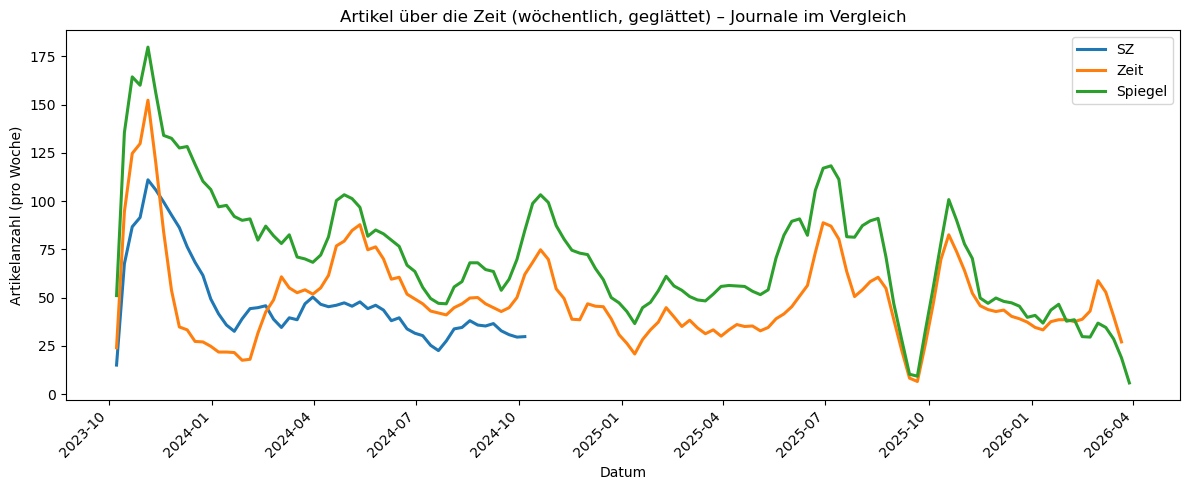

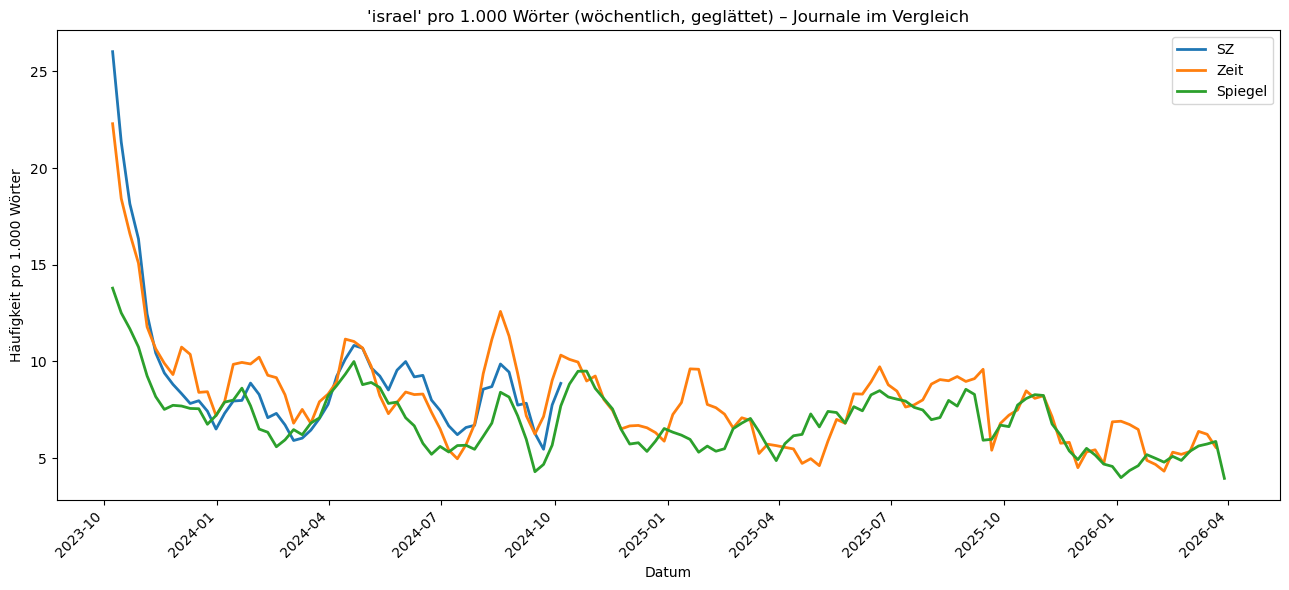

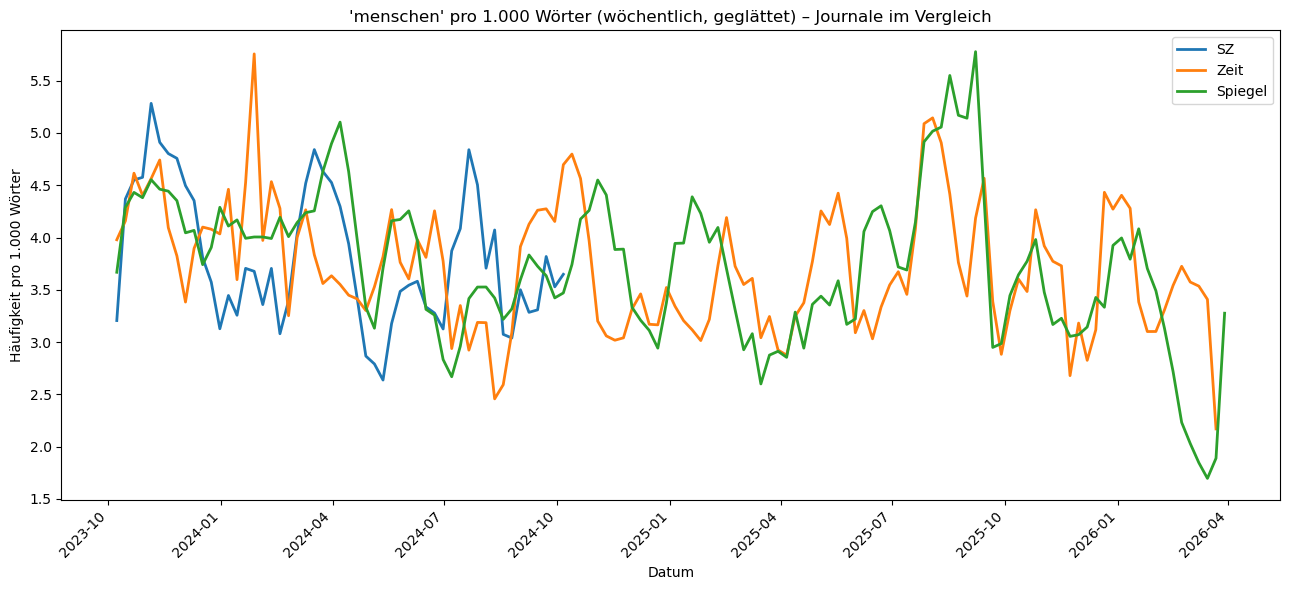

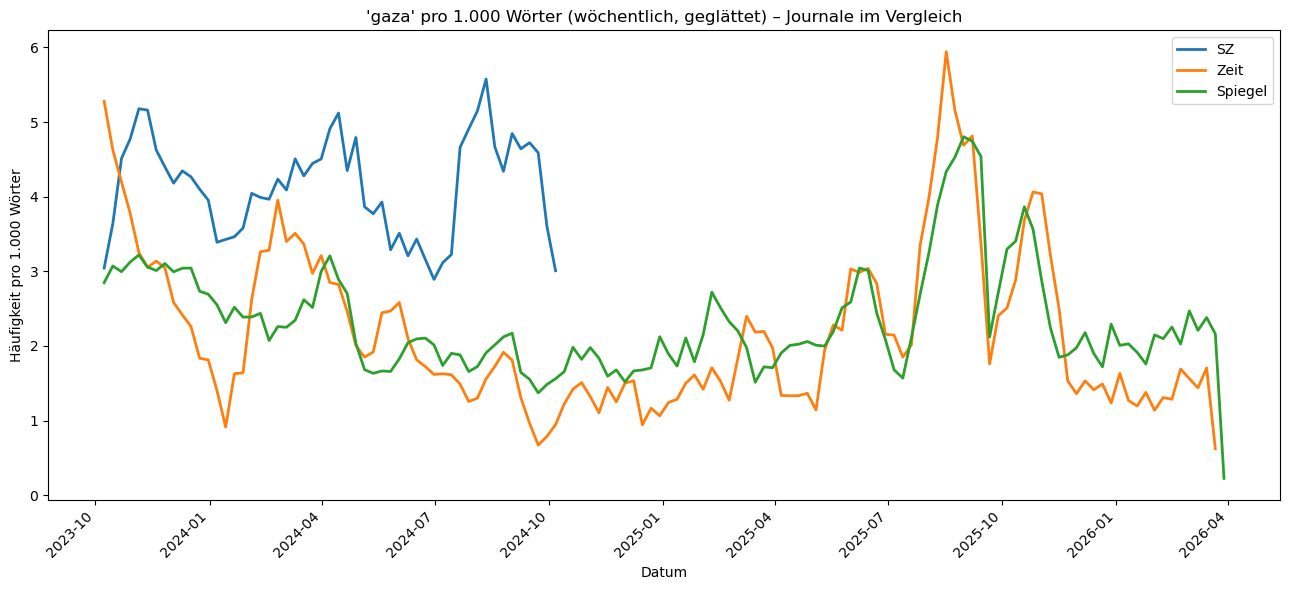

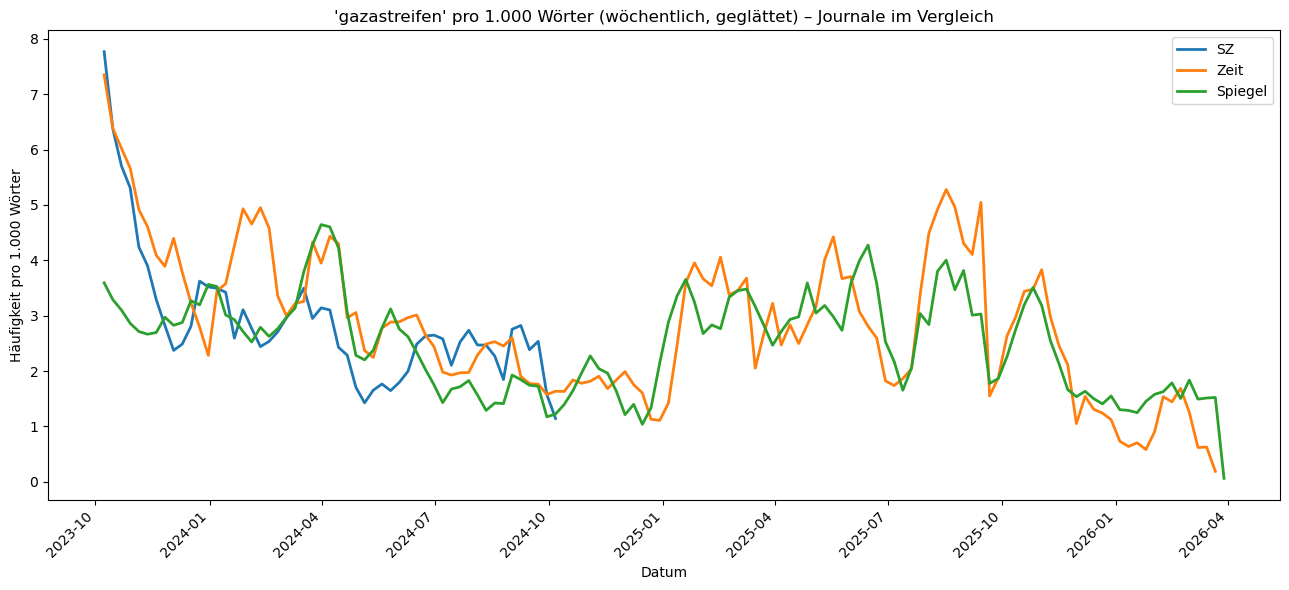

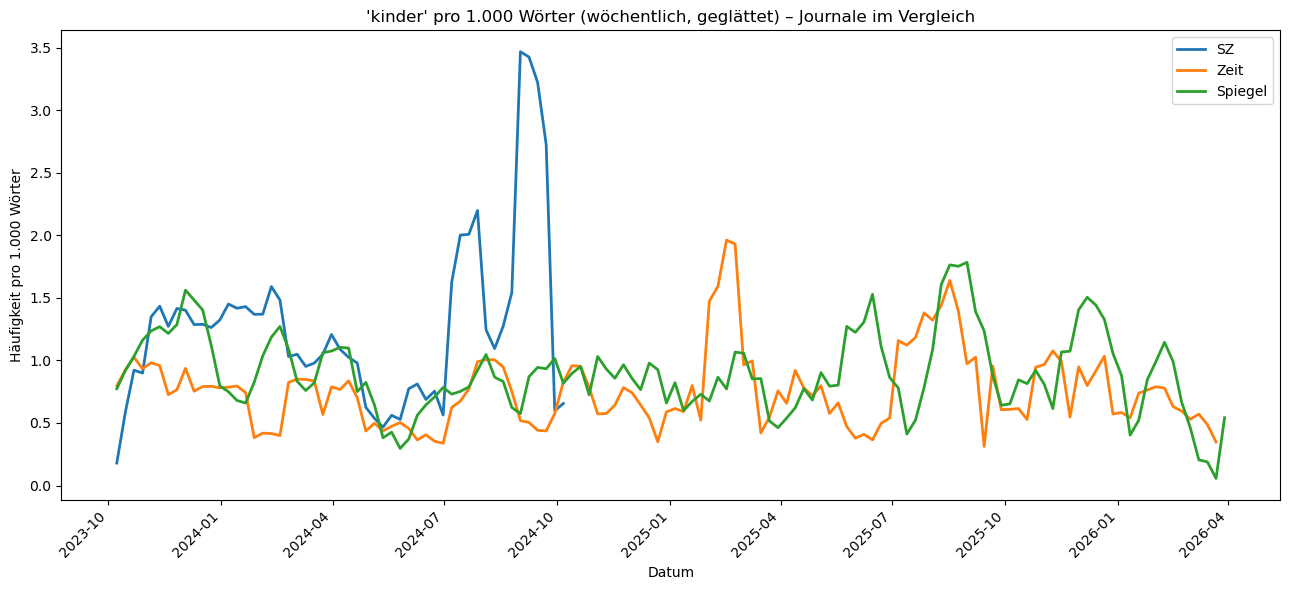

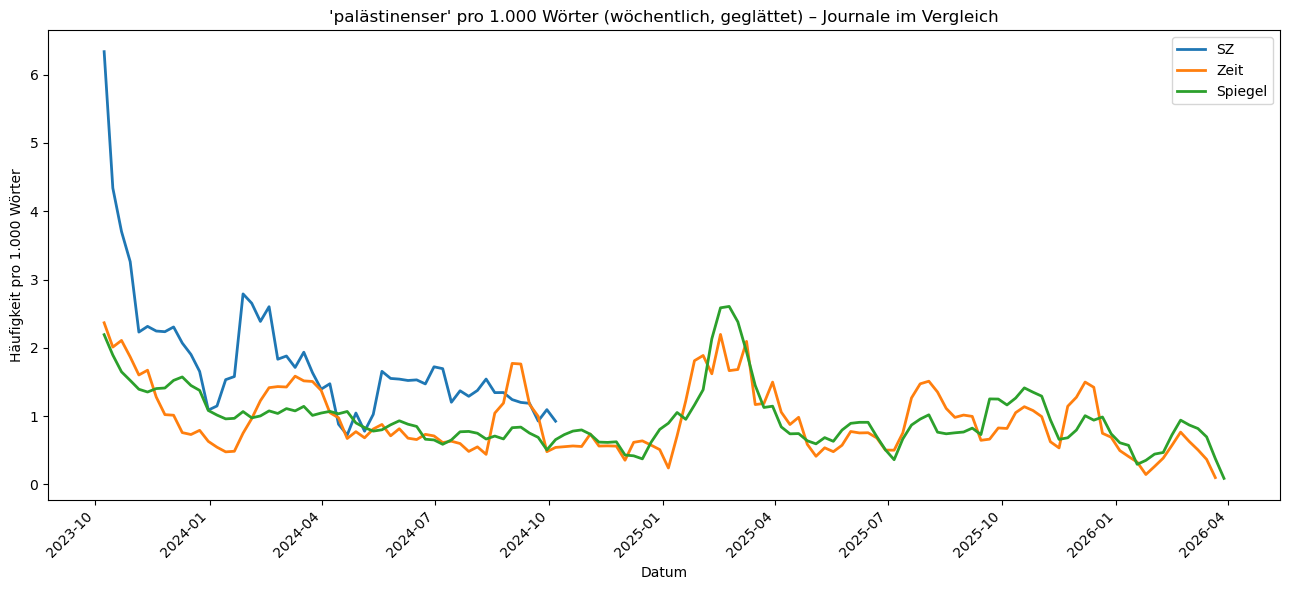

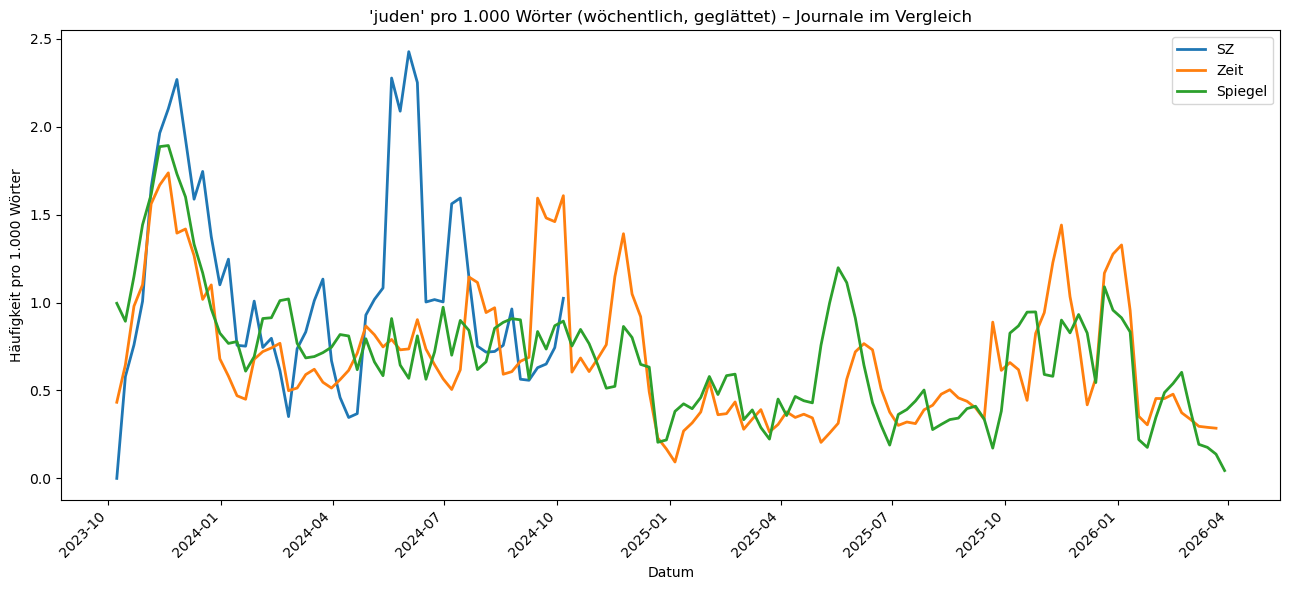

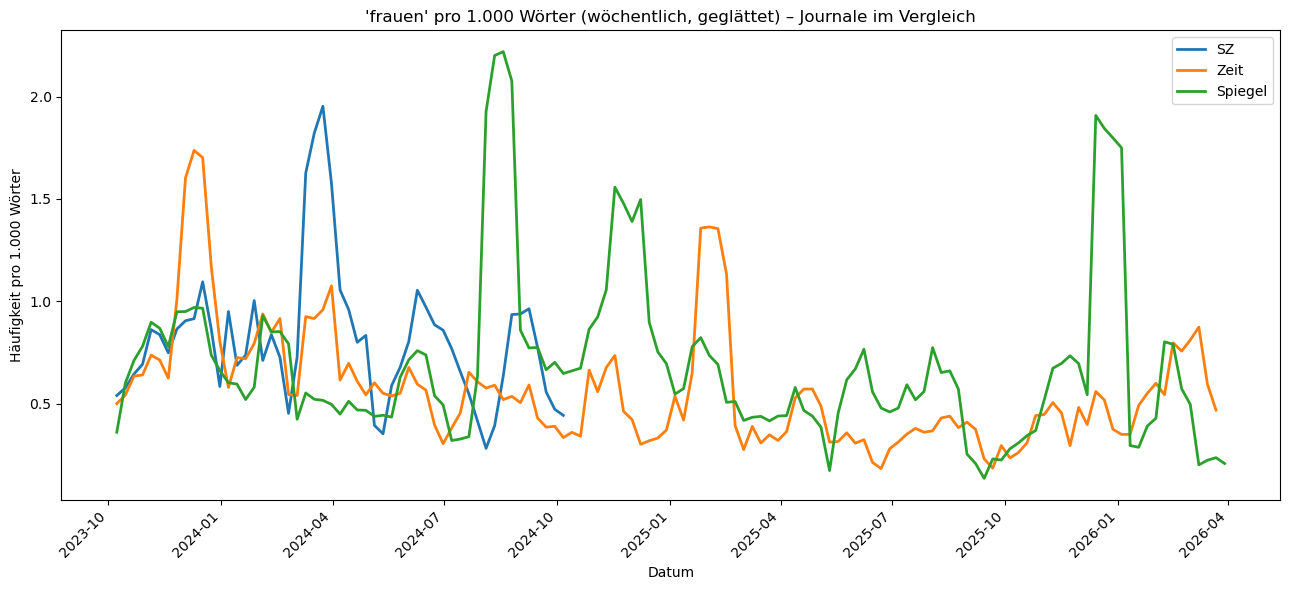

Saved plots: time_articles_per_week_smoothed_MULTI.png and per-keyword comparison plots.


In [49]:
main()

SZ: files=2522, tokenized=2522, read_failures=0
Zeit: files=6281, tokenized=6281, read_failures=0
Spiegel: files=9190, tokenized=9190, read_failures=0
Saved test5_descriptor_asymmetry_SZ.csv
Saved test5_descriptor_asymmetry_Zeit.csv
Saved test5_descriptor_asymmetry_Spiegel.csv


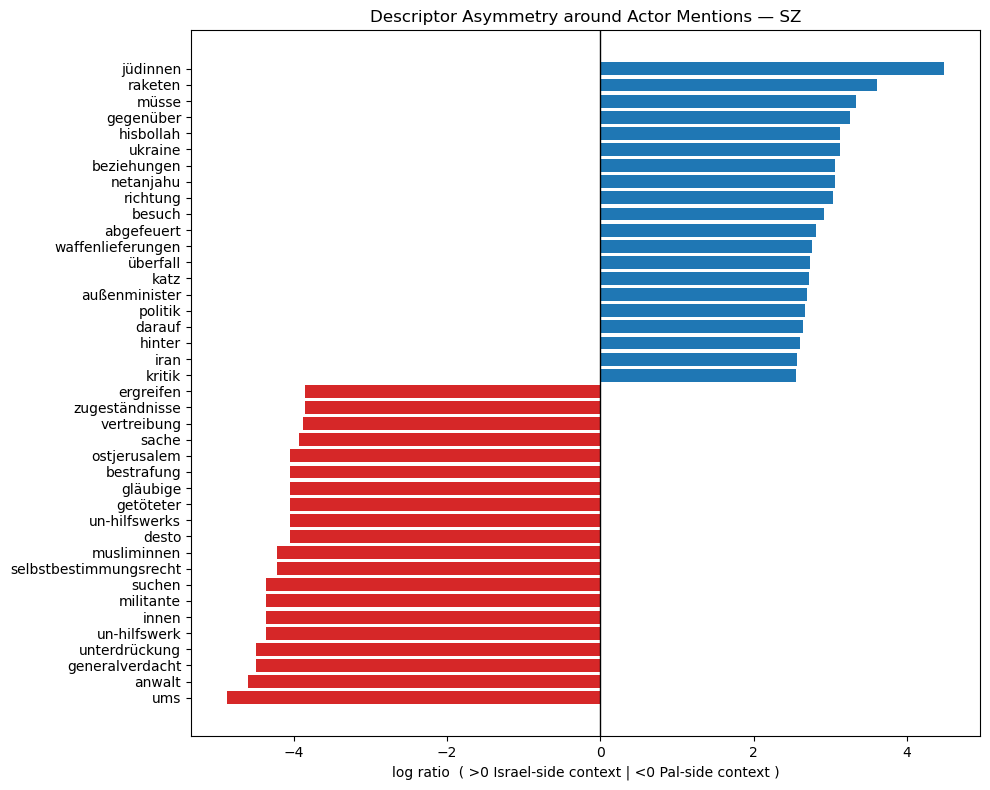

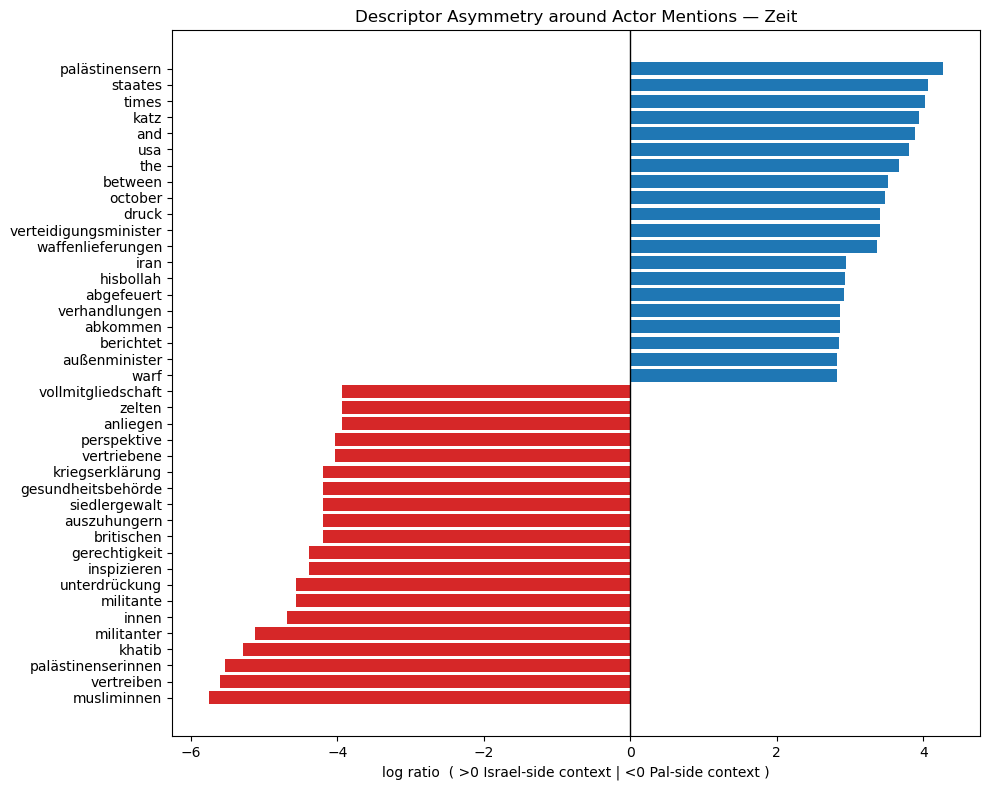

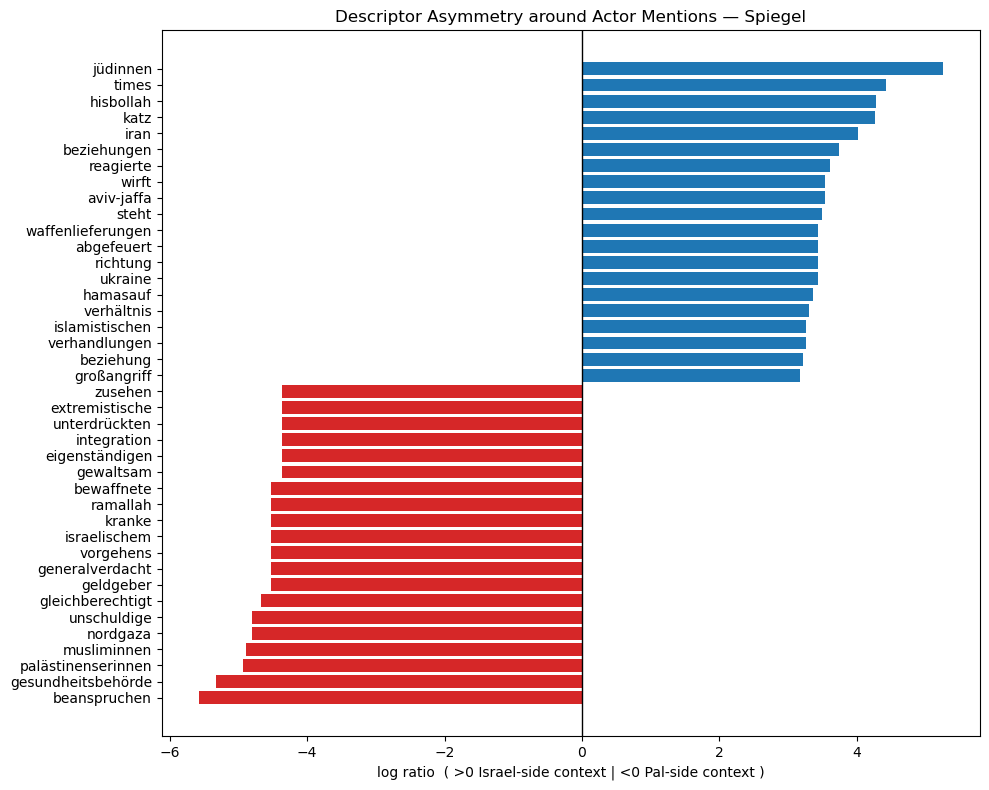

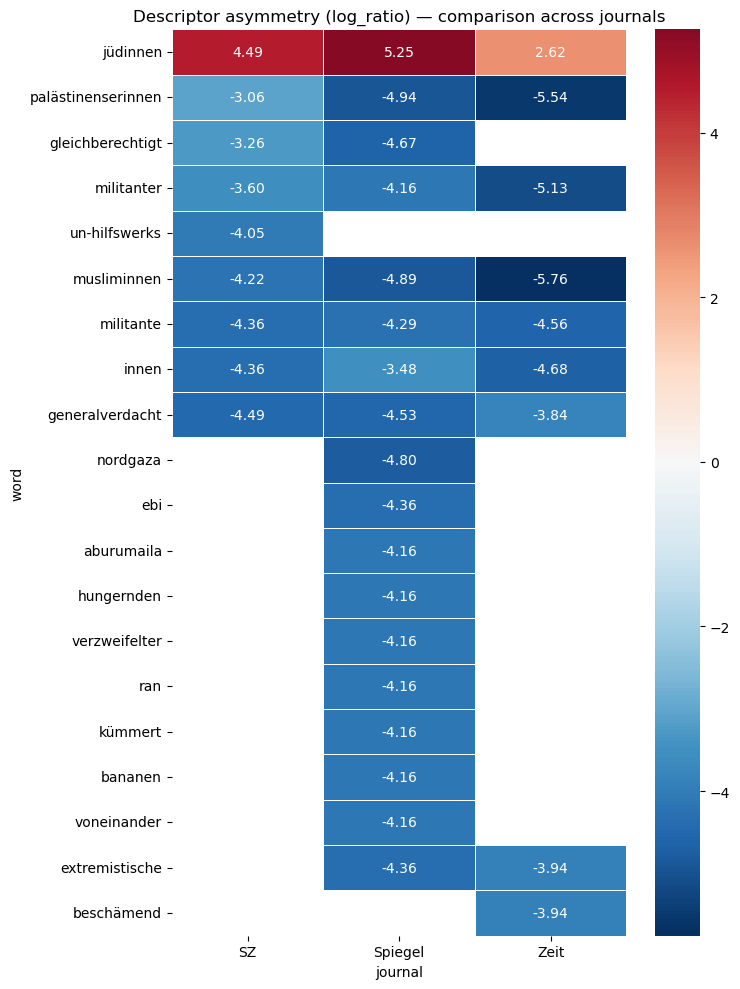

Saved test5_descriptor_asymmetry_compare_heatmap.png
Saved test5_descriptor_asymmetry_compare_heatmap_data.csv


In [50]:
# bias_advanced_tests.py
from pathlib import Path
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


# =========================
# CONFIG
# =========================
#DATA_DIR = Path("articles")
MAX_FILES = None
MIN_WORD_LEN = 3
WINDOW = 1                 # context window for descriptor asymmetry
COOC_MIN_EDGE = 25         # min co-occurrence count to draw edge
TOP_DESCRIPTOR_N = 20
FREQ = "W"                 # weekly aggregation for trends
ROLL = 2                   # smoothing window (weeks)

EVENT_DATES = [
    "2023-10-08",
    "2024-01-24",
    "2024-10-01",
]


# --- your keywords (deduplicated + lowercase during processing)
KEYWORDS = [
    "Geisel","Freiheit","Schlachtruf","Dörfer","Opfer","Schuld","Parole","Städte","Zivilisten","Vergebung",
    "Menschliches Schutzschild","Gaza","Kinder","Sieg","Machtmissbrauch","Gazastreifen","Minderjährige",
    "Selbstverteidigung","Vergeltungsschlag","Israel","Jugendliche","Demokratie","Handlungsspielraum","Exil",
    "Junge","Toleranz","Barbarei","Diaspora","Mädchen","Propaganda","Infrastruktur","Baby","Schmerz",
    "Verbrechen Menschlichkeit","Grenzübergang","Säugling","Solidarität","Kontroverse","Umstrittene Gebiete",
    "Gefangene","Legitimität","Terrorsymbol","Palästinenserstaat","Frauen","Rechtfertigung","Bestialität",
    "Tunnel","Männer","Sicherheit","Kälte","Tunnelnetz","Alte","Gerechtigkeit","Korruption","sichere Zone",
    "Juden","Schutz","Protest","Schutzbunker","Muslime","Vergeltung","Straßenprotest","Territorium",
    "Palästinenser","Hass","Demonstration","Kriegszone","Israelis","Rache","Recht","Kriegsgebiet","Menschen",
    "Lust","Gesetz","Naher Osten","Bürger","Gelüste","Existenzrecht","Mittlerer Osten","Einwohner","Zuflucht",
    "Verbot","Gefängnis","Bewohner","Überleben","Hassworte","Käfig","Widerstand","Gewalttaten","Wohnhäuser",
    "Versammlung","Kommandozentrale","Christen","Trauer","Kundgebung","Arabischer Staat","Homosexuelle",
    "Schrecken","Versammlungsrecht","Besetztes Gebiet","Araber","Gedenken","Hetzparolen","Massengrab",
    "Krankenhaus","AusnahmesituationKindermörder","Schlachtfeld","Journalist","Not","Hilfe","Schutzraum",
    "Klinik","Notsituation","Hilfslieferung","Schutzzone","Patienten","Leid","Blockade","Krisengebiet","Ärzte",
    "Koexoistence","Sanktion","Sanitäter","Bedrohung","Abriegelung","Vorort","Leichen","Frieden","Bombardement",
    "Gaza-Stadt","Leichenberge","Deeskalation","Rakete","Ziele","Töchter","Versöhnung","Bombe","urbanes Gelände",
    "Söhne","Rettung","Bombardierung","Front","Väter","Kontext","Völerrecht","Westjordanland","Mütter",
    "Stellvertreterkrieg","Hilfsgüter","Region","Großmütter","Rebellion","Unterstützung","Schule","Enkel",
    "Freiheitskampf","Zwei-Staaten-Lösung","Kindergärten","Personen","Kolonialismus","Flugabwehr","geschützte Plätze",
    "Staatsbürger","Apartheid","Bombenhagel","Häuserblock","Familien","Wasser","Entlassung","geschützter Korridor",
    "Mitbürger","Brot","Gewaltspirale","Fluchtkorridor","palästinensisches Volk","Hunger","Kritik","Fläche",
    "Bevölkerung","Feuerpause","Nahostkonflikt","Flüchtlingslager","Arbeitskräfte","Kollektivbestrafung","Vermisste",
    "UN-Resolution","Geflüchtete","Todesstrafe","Flüchtlinge","Gefangenenaustausch","Entführte","Fake News"
]

# Frame dictionaries (edit as you like)
FRAMES = {
    "security_military": [
        "sicherheit","selbstverteidigung","rakete","bombe","bombardement","bombardierung",
        "tunnel","tunnelnetz","kommandozentrale","kriegsgebiet","kriegszone","schlachtfeld","front"
    ],
    "humanitarian": [
        "zivilisten","kinder","leid","hilfe","hilfsgüter","hilfslieferung","flüchtlinge","geflüchtete",
        "krankenhaus","klinik","patienten","schutzraum","schutzzone","überleben","hunger","wasser"
    ],
    "legal_normative": [
        "recht","gesetz","legitimität","un-resolution","existenzrecht","völerrecht","gerechtigkeit","demokratie"
    ],
    "protest_politics": [
        "protest","demonstration","kundgebung","versammlungsrecht","kritik","kontroverse","korruption","apartheid"
    ],
}

ACTOR_GROUPS = {
    "israel_side": ["israel", "israelis", "juden","israeli"],
    "pal_side": ["palästinenser", "palästinensisches volk", "palästinenserstaat", "araber", "muslime"],
}

# =========================
# HELPERS
# =========================
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s\-]", " ", text)
    words = text.split()
    return [w for w in words if len(w) >= MIN_WORD_LEN and w not in STOPWORDS]

def parse_date(first_line):
    m = re.match(r"^\s*(\d{2}\.\d{2}\.\d{4})\s*(.*)$", first_line.strip())
    if not m:
        return pd.NaT, ""
    dt = pd.to_datetime(m.group(1), format="%d.%m.%Y", errors="coerce")
    cat = m.group(2).strip()
    return dt, cat

def count_terms(tokens, terms):
    c = Counter(tokens)
    joined = " ".join(tokens)
    out = {}
    for t in terms:
        k = t.lower().strip()
        if " " in k:
            out[k] = len(re.findall(r"(?<!\S)" + re.escape(k) + r"(?!\S)", joined))
        else:
            out[k] = c.get(k, 0)
    return out

def smooth_series(s, roll=4):
    return s.rolling(roll, min_periods=1).mean()

# =========================
# LOAD DATA
# =========================
files = []
for journal, data_dir in JOURNAL_DIRS.items():
    files.extend(sorted(data_dir.glob("*.txt")))

if MAX_FILES is not None:
    files = files[:MAX_FILES]

records = []
doc_tokens = {}  # for co-occurrence + descriptor tests

keywords_clean = sorted(set([k.lower().strip() for k in KEYWORDS if k.strip()]))

for fp in files:
    txt = fp.read_text(encoding="utf-8", errors="ignore")
    lines = txt.splitlines()
    first = lines[0] if lines else ""
    dt, cat = parse_date(first)
    if pd.isna(dt):
        continue

    body = "\n".join(lines[1:]) if len(lines) > 1 else ""
    tokens = tokenize(body)
    doc_tokens[fp.name] = tokens

    kw = count_terms(tokens, keywords_clean)

    rec = {
        "file": fp.name,
        "date": dt.normalize(),
        "category": cat,
        "token_count": len(tokens),
    }
    rec.update(kw)
    records.append(rec)

df = pd.DataFrame(records).sort_values("date")
if df.empty:
    raise ValueError("No valid articles parsed.")

for c in df.columns:
    if c not in {"file","date","category"}:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

keyword_cols = [c for c in df.columns if c not in {"file","date","category","token_count"}]


# =========================
# TEST 5 (MULTI): Descriptor asymmetry by actor (±WINDOW) per journal + comparison
# Requires:
#   - JOURNAL_DIRS: {"SZ": Path(...), "Zeit": Path(...), ...}
#   - tokenize(text) uses STOPWORDS, MIN_WORD_LEN
#   - ACTOR_GROUPS, WINDOW, TOP_DESCRIPTOR_N, MIN_WORD_LEN, STOPWORDS
#   - filenames contain dates but we do NOT need dates for this test
# =========================

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

actor_terms = {k: [t.lower() for t in v] for k, v in ACTOR_GROUPS.items()}
assert set(actor_terms.keys()) == {"israel_side", "pal_side"}, "This code expects exactly israel_side and pal_side."

def descriptor_asymmetry_for_tokens(doc_tokens, window=WINDOW):
    """
    doc_tokens: dict[file -> list[str]]
    returns:
      desc_counts: {"israel_side": Counter, "pal_side": Counter}
      desc_df: DataFrame with per-word log_ratio and counts
    """
    desc_counts = {k: Counter() for k in actor_terms}

    for toks in doc_tokens.values():
        n = len(toks)
        for i, tok in enumerate(toks):
            # note: matching is token-based; multiword actor terms won't match here
            for grp, terms in actor_terms.items():
                if tok in terms:
                    l = max(0, i - window)
                    r = min(n, i + window + 1)
                    ctx = toks[l:i] + toks[i+1:r]
                    for w in ctx:
                        if len(w) >= MIN_WORD_LEN and w not in STOPWORDS:
                            desc_counts[grp][w] += 1

    # log-odds style asymmetry
    all_words = set(desc_counts["israel_side"]) | set(desc_counts["pal_side"])
    total_i = sum(desc_counts["israel_side"].values()) + 1
    total_p = sum(desc_counts["pal_side"].values()) + 1

    rows = []
    for w in all_words:
        ci = desc_counts["israel_side"][w] + 0.5
        cp = desc_counts["pal_side"][w] + 0.5
        score = np.log((ci / total_i) / (cp / total_p))  # >0 israel-context, <0 pal-context
        rows.append({
            "word": w,
            "israel_ctx_count": ci - 0.5,
            "pal_ctx_count": cp - 0.5,
            "log_ratio": score
        })

    desc_df = pd.DataFrame(rows).sort_values("log_ratio", ascending=False)
    return desc_counts, desc_df

# -------------------------
# Load per-journal tokens
# -------------------------
journal_doc_tokens = {}
fail_counts = Counter()

for journal, data_dir in JOURNAL_DIRS.items():
    files = sorted(data_dir.glob("*.txt"))
    if MAX_FILES is not None:
        files = files[:MAX_FILES]

    doc_tokens = {}
    for fp in files:
        try:
            text = fp.read_text(encoding="utf-8", errors="ignore")
        except Exception:
            fail_counts[journal] += 1
            continue

        toks = tokenize(text)  # do NOT strip first line; your current pipeline keeps full text
        doc_tokens[fp.name] = toks

    journal_doc_tokens[journal] = doc_tokens
    print(f"{journal}: files={len(files)}, tokenized={len(doc_tokens)}, read_failures={fail_counts[journal]}")

# -------------------------
# Compute descriptor asymmetry per journal
# -------------------------
journal_desc = {}  # journal -> desc_df
for journal, dtoks in journal_doc_tokens.items():
    _, desc_df = descriptor_asymmetry_for_tokens(dtoks, window=WINDOW)
    desc_df["journal"] = journal
    journal_desc[journal] = desc_df
    desc_df.to_csv(f"test5_descriptor_asymmetry_{journal}.csv", index=False, encoding="utf-8")
    print(f"Saved test5_descriptor_asymmetry_{journal}.csv")

# -------------------------
# Plot: per journal (same style as your single-journal plot)
# -------------------------
for journal, desc_df in journal_desc.items():
    if desc_df.empty:
        print(f"{journal}: descriptor df empty (no actor mentions matched).")
        continue

    top_pos = desc_df.head(TOP_DESCRIPTOR_N).copy()
    top_neg = desc_df.tail(TOP_DESCRIPTOR_N).copy()
    plot_df = pd.concat([top_neg, top_pos]).sort_values("log_ratio")

    colors = ["#d62728" if x < 0 else "#1f77b4" for x in plot_df["log_ratio"]]

    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["word"], plot_df["log_ratio"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Descriptor Asymmetry around Actor Mentions — {journal}")
    plt.xlabel("log ratio  ( >0 Israel-side context | <0 Pal-side context )")
    plt.tight_layout()
    plt.savefig(f"test5_descriptor_asymmetry_{journal}.png", dpi=220)
    plt.show()

# -------------------------
# Comparative view: same words across journals (top words by |log_ratio| overall)
# -------------------------
all_desc = pd.concat(journal_desc.values(), ignore_index=True)
if not all_desc.empty:
    # pick globally most asymmetric words (by mean abs across journals)
    pivot = all_desc.pivot_table(index="word", columns="journal", values="log_ratio", aggfunc="mean")
    word_strength = pivot.abs().mean(axis=1).sort_values(ascending=False)
    top_words = word_strength.head(TOP_DESCRIPTOR_N).index.tolist()

    heat = pivot.loc[top_words].sort_values(by=pivot.columns[0], ascending=False, na_position="last")

    plt.figure(figsize=(1.2 * len(pivot.columns) + 4, 0.35 * len(top_words) + 3))
    import seaborn as sns
    sns.heatmap(heat, center=0, cmap="RdBu_r", annot=True, fmt=".2f", linewidths=0.5)
    plt.title("Descriptor asymmetry (log_ratio) — comparison across journals")
    plt.tight_layout()
    plt.savefig("test5_descriptor_asymmetry_compare_heatmap.png", dpi=220)
    plt.show()

    heat.to_csv("test5_descriptor_asymmetry_compare_heatmap_data.csv", encoding="utf-8")
    print("Saved test5_descriptor_asymmetry_compare_heatmap.png")
    print("Saved test5_descriptor_asymmetry_compare_heatmap_data.csv")
else:
    print("No descriptor data to compare (check actor term matching / tokenization).")

In [7]:
# Cell 1: config
ATTRIBUTION_CUES = [
    # core
    "laut", "zufolge", "nach angaben", "angaben zufolge", "nach informationen",
    "wie es hieß", "wie verlautete", "demnach", "dem bericht zufolge",

    # reporting verbs (common German news style)
    "sagte", "sagte dazu", "er sagte", "sie sagte", "teilte mit", "mitgeteilt",
    "erklärte", "äußerte", "betonte", "berichtete", "meldete", "verkündete",
    "gab an", "gaben an", "bestätigte", "bestätigten", "dementierte",
    "widersprach", "kündigte an", "räumte ein", "warnte", "so",
    "hieß es", "verlautete", "so der", "so die", "so das",

    # journalistic evidence markers
    "nach berichten", "medienberichten zufolge", "wie die zeitung berichtet",
    "wie die agentur meldet", "nach dpa-informationen", "dpa zufolge",
    "reuters zufolge", "afp zufolge", "ap zufolge",

    # authority/institution attribution anchors
    "nach angaben der regierung", "nach angaben des militärs", "nach angaben der armee",
    "nach angaben der polizei", "nach angaben der behörden", "nach angaben des ministeriums",
    "teilte das ministerium mit", "teilte die armee mit", "teilte die regierung mit",
    "sagte ein sprecher", "sagte eine sprecherin", "so ein sprecher", "so eine sprecherin",

    # uncertainty + attribution combo markers
    "nach eigenen angaben", "nach israelischen angaben", "nach palästinensischen angaben",
    "nach angaben aus", "von offizieller seite", "aus kreisen", "aus sicherheitskreisen"
]
ATTR_WINDOW = 5

In [8]:
# Cell 2: helper
def phrase_in_window(window_tokens, phrase):
    p = phrase.split()
    if len(p) == 1:
        return p[0] in window_tokens
    # phrase match in token window
    for i in range(len(window_tokens) - len(p) + 1):
        if window_tokens[i:i+len(p)] == p:
            return True
    return False

# Replacement Cell 2: substring-based cue matching (better for German phrasing)
def has_attribution_cue(window_tokens, cues):
    window_text = " ".join(window_tokens)
    return any(cue in window_text for cue in cues)

,group,mentions,with_attribution,without_attribution,attribution_rate
0,israel_side,13340,2842,10498,0.213043
1,pal_side,2554,487,2067,0.190681


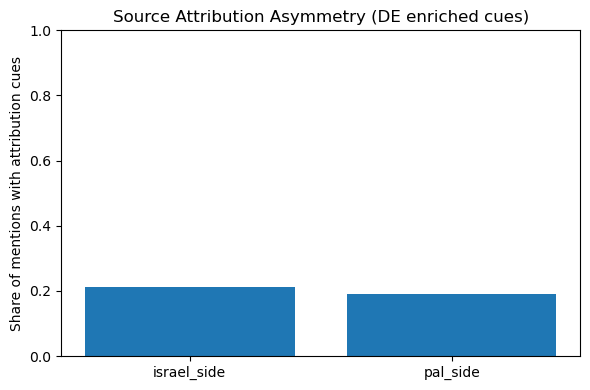

In [9]:
# Replacement Cell 3: rerun attribution asymmetry
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

actor_terms = {k:[t.lower() for t in v] for k,v in ACTOR_GROUPS.items()}
cue_list = [c.lower() for c in ATTRIBUTION_CUES]

counts = {
    grp: Counter({"mentions":0, "with_attribution":0, "without_attribution":0})
    for grp in actor_terms
}

for toks in doc_tokens.values():
    n = len(toks)
    for i, tok in enumerate(toks):
        for grp, terms in actor_terms.items():
            if tok in terms:
                counts[grp]["mentions"] += 1
                l = max(0, i-ATTR_WINDOW)
                r = min(n, i+ATTR_WINDOW+1)
                window = toks[l:r]
                if has_attribution_cue(window, cue_list):
                    counts[grp]["with_attribution"] += 1
                else:
                    counts[grp]["without_attribution"] += 1

rows = []
for grp, c in counts.items():
    m = c["mentions"]
    rate = (c["with_attribution"] / m) if m > 0 else np.nan
    rows.append({
        "group": grp,
        "mentions": m,
        "with_attribution": c["with_attribution"],
        "without_attribution": c["without_attribution"],
        "attribution_rate": rate
    })

attr_df = pd.DataFrame(rows)
display(attr_df)

plt.figure(figsize=(6,4))
plt.bar(attr_df["group"], attr_df["attribution_rate"])
plt.ylim(0, 1)
plt.ylabel("Share of mentions with attribution cues")
plt.title("Source Attribution Asymmetry (DE enriched cues)")
plt.tight_layout()
plt.show()

In [10]:
# Attribution profile by actor side + authority weighting
from collections import defaultdict, Counter
import pandas as pd
import numpy as np

# 1) classify cues by authority level (edit as you like)
HIGH_AUTH = {
    "nach angaben der regierung", "nach angaben des militärs", "nach angaben der armee",
    "nach angaben der polizei", "nach angaben der behörden", "nach angaben des ministeriums",
    "teilte das ministerium mit", "teilte die armee mit", "teilte die regierung mit",
    "dpa zufolge", "reuters zufolge", "afp zufolge", "ap zufolge"
}
MID_AUTH = {
    "nach angaben", "angaben zufolge", "nach informationen", "nach berichten",
    "medienberichten zufolge", "wie die agentur meldet", "wie die zeitung berichtet",
    "bestätigte", "bestätigten", "teilte mit", "erklärte", "berichtete", "meldete"
}
# everything else -> LOW_AUTH

def cue_level(c):
    if c in HIGH_AUTH:
        return "high"
    if c in MID_AUTH:
        return "mid"
    return "low"

level_weight = {"high": 3, "mid": 2, "low": 1}

actor_terms = {k:[t.lower() for t in v] for k,v in ACTOR_GROUPS.items()}
cue_list = [c.lower() for c in ATTRIBUTION_CUES]

# 2) count exact cue hits near actor mentions
cue_counts_by_group = {g: Counter() for g in actor_terms}
mention_counts = Counter()

for toks in doc_tokens.values():
    n = len(toks)
    for i, tok in enumerate(toks):
        for grp, terms in actor_terms.items():
            if tok in terms:
                mention_counts[grp] += 1
                l = max(0, i-ATTR_WINDOW)
                r = min(n, i+ATTR_WINDOW+1)
                wtxt = " ".join(toks[l:r])

                for cue in cue_list:
                    if cue in wtxt:
                        cue_counts_by_group[grp][cue] += 1

# 3) long table
rows = []
for grp, cnt in cue_counts_by_group.items():
    for cue, c in cnt.items():
        lvl = cue_level(cue)
        rows.append({
            "group": grp,
            "cue": cue,
            "count": c,
            "per_100_mentions": (c / mention_counts[grp] * 100) if mention_counts[grp] else np.nan,
            "authority_level": lvl,
            "authority_weight": level_weight[lvl]
        })

cue_df = pd.DataFrame(rows).sort_values(["group","count"], ascending=[True, False])
display(cue_df.head(30))

# 4) group-level authority score
auth_rows = []
for grp in actor_terms:
    sub = cue_df[cue_df["group"] == grp].copy()
    weighted_sum = (sub["count"] * sub["authority_weight"]).sum()
    total_hits = sub["count"].sum()
    avg_auth = (weighted_sum / total_hits) if total_hits > 0 else np.nan
    auth_rows.append({
        "group": grp,
        "mentions": mention_counts[grp],
        "attribution_hits": total_hits,
        "avg_authority_score_1to3": avg_auth
    })

auth_df = pd.DataFrame(auth_rows)
display(auth_df)

# optional saves
cue_df.to_csv("attribution_cue_profile_by_side.csv", index=False, encoding="utf-8")
auth_df.to_csv("attribution_authority_summary_by_side.csv", index=False, encoding="utf-8")

,group,cue,count,per_100_mentions,authority_level,authority_weight
1,israel_side,so,2480,18.590705,low,1
4,israel_side,laut,147,1.101949,low,1
3,israel_side,erklärte,70,0.524738,mid,2
10,israel_side,zufolge,48,0.359820,low,1
6,israel_side,berichtete,28,0.209895,mid,2
9,israel_side,betonte,21,0.157421,low,1
14,israel_side,äußerte,21,0.157421,low,1
13,israel_side,warnte,20,0.149925,low,1
2,israel_side,sagte,17,0.127436,low,1
8,israel_side,meldete,14,0.104948,mid,2


,group,mentions,attribution_hits,avg_authority_score_1to3
0,israel_side,13340,2926,1.043062
1,pal_side,2554,506,1.017787
